In [73]:
import pandas as pd
import matplotlib 
from matplotlib import pyplot as plt
import numpy as np

all_params = pd.read_csv("./all_params.csv", index_col="idx")
all_params.index.names = ["tree_idx"]
mle_estimates = pd.read_csv("./mle_results_bldp_exact/mle_estimates.csv", index_col="tree_idx").assign(model="MLE")
deep_estimates = pd.read_csv("./parameter_estimates/all_phylodeep_results.csv", index_col="tree_idx").assign(model="Phylodeep")

all_params.head()


FileNotFoundError: [Errno 2] No such file or directory: './parameter_estimates/all_phylodeep_results.csv'

In [ ]:
mle_estimates.head()

,n_tips,true_mu,true_lambda,mle_mu,mle_lambda,ll,model
tree_idx,,,,,,,
0,285,0.280,0.402,0.510671,0.638339,1622.601530,MLE
1,320,0.304,0.727,0.191613,0.383032,1279.187315,MLE
10,463,0.281,0.785,0.415615,0.685752,1647.418561,MLE
100,102,0.700,0.759,0.267688,0.718925,367.944104,MLE
1000,378,0.411,0.567,0.133855,0.167319,1916.380335,MLE


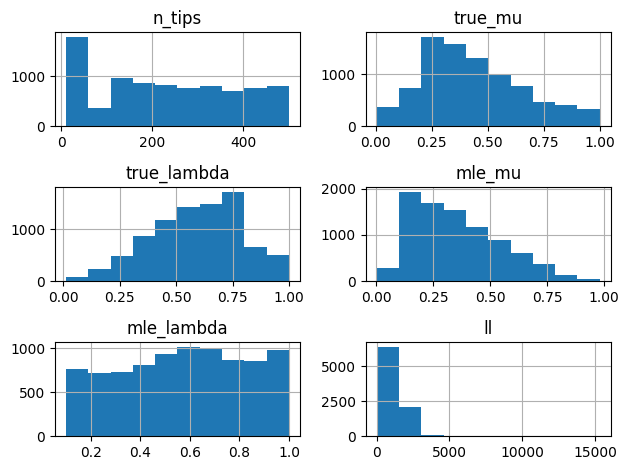

In [74]:
mle_estimates.hist()
plt.tight_layout()

In [75]:
deep_estimates.head()

,tip_size,true_lambda,true_mu,R0,infectious_period,mu,lambda,success,model
tree_idx,,,,,,,,,
5470,50,NaN,NaN,1.457854,1.336562,0.748188,1.090749,True,Phylodeep
7460,50,NaN,NaN,1.140366,1.177454,0.849290,0.968501,True,Phylodeep
4555,50,NaN,NaN,4.788179,7.078835,0.141266,0.676408,True,Phylodeep
6092,50,NaN,NaN,3.899858,4.219173,0.237013,0.924318,True,Phylodeep
8534,50,NaN,NaN,1.086004,1.395284,0.716700,0.778339,True,Phylodeep


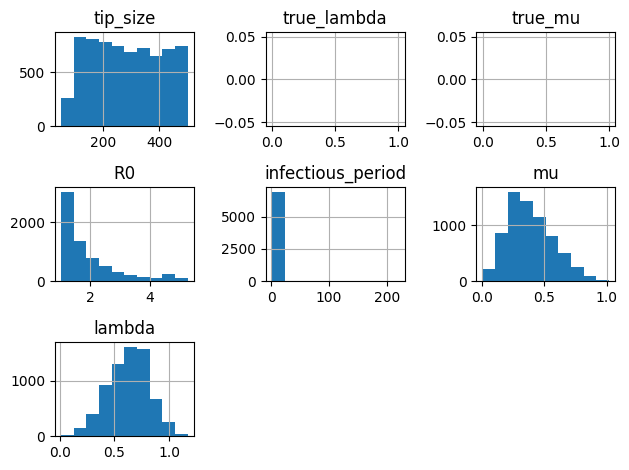

In [76]:
deep_estimates.hist()
plt.tight_layout()

In [77]:
true_params = all_params[["R", "la_II", "psi_I", "tips"]].rename(columns={"R": "R_naught", "la_II": "lambda_true", "psi_I": "mu_true"})

model_comparison_mle = pd.merge(
    true_params,
    mle_estimates[["mle_lambda", "mle_mu"]],
    left_index=True, right_index=True, how="outer"
).reset_index().assign(model="MLE").rename(columns={"mle_lambda": "lambda", "mle_mu": "mu"})

model_comparison_deep = pd.merge(
    true_params,
    deep_estimates[["lambda", "mu"]],
    left_index=True, right_index=True, how="outer"
).reset_index().assign(model="Phylodeep")

long_data = pd.concat([model_comparison_mle, model_comparison_deep], axis=0)

lambda_compare = long_data[["lambda_true", "lambda", "model", "tips"]].rename(columns={"lambda_true": "true_value", "lambda": "estimate"}).assign(parameter="lambda")
mu_compare = long_data[["mu_true", "mu", "model", "tips"]].rename(columns={"mu_true": "true_value", "mu": "estimate"}).assign(parameter="mu")

long_data = pd.concat([lambda_compare, mu_compare], axis=0)
long_data.head()



,true_value,estimate,model,tips,parameter
0,0.402,0.638339,MLE,285,lambda
1,0.727,0.383032,MLE,320,lambda
2,0.785,0.734937,MLE,187,lambda
3,0.749,0.995610,MLE,491,lambda
4,0.727,0.616350,MLE,286,lambda


In [78]:
long_data["err"] = long_data["true_value"] - long_data["estimate"]
long_data.head()

,true_value,estimate,model,tips,parameter,err
0,0.402,0.638339,MLE,285,lambda,-0.236339
1,0.727,0.383032,MLE,320,lambda,0.343968
2,0.785,0.734937,MLE,187,lambda,0.050063
3,0.749,0.995610,MLE,491,lambda,-0.246610
4,0.727,0.616350,MLE,286,lambda,0.110650


In [79]:
def rmse(x):
    return np.sqrt(np.mean(x**2))

def boot_rmse(x, n_boot=250):
    boot_samples = np.random.choice(x, size=(n_boot, len(x)), replace=True)
    boot_rmses = np.sqrt(np.mean(boot_samples**2, axis=1))
    return boot_rmses

def boot_rmse_mean(*args, **kwargs):
    return np.mean(boot_rmse(*args, **kwargs))

def boot_rmse_std(*args, **kwargs):
    return np.std(boot_rmse(*args, **kwargs))

# long_data.groupby("model")["err"].apply(boot_rmse)

long_data.dropna().groupby(["model", "parameter"])["err"].apply(boot_rmse_mean)

model      parameter
MLE        lambda       0.308482
           mu           0.296525
Phylodeep  lambda       0.041970
           mu           0.034867
Name: err, dtype: float64

0 lambda
1 mu


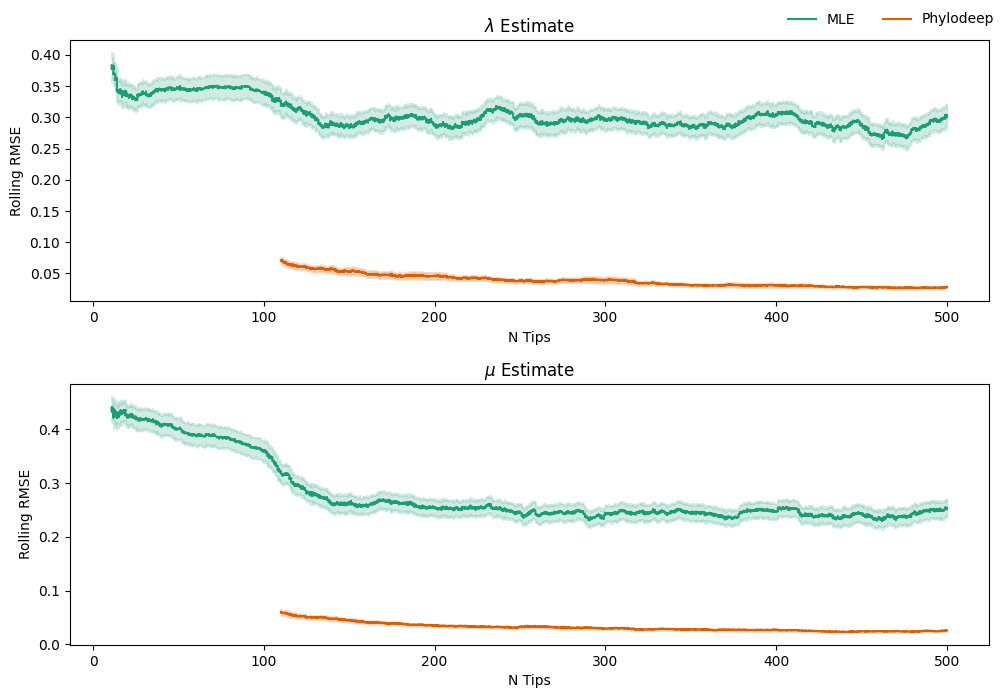

In [70]:
cmap = matplotlib.colormaps["Dark2"]

fig, ax = plt.subplots(figsize=(10, 7), nrows=2)
for j, (param, sub_df) in enumerate(long_data.groupby("parameter")):
    print(j, param)
    for i, (model_name, group_df) in enumerate(sub_df.groupby("model")):
        sort_df = group_df.sort_values("tips", ascending=True, inplace=False)
        roll_rmse = sort_df.rolling(window=500)["err"].apply(boot_rmse_mean)
        roll_std = sort_df.rolling(window=500)["err"].apply(boot_rmse_std)
        
        roll_ci_se = 1.96 * roll_std 
        low, high = roll_rmse - roll_ci_se, roll_rmse + roll_ci_se

        rmse_ests = sort_df.rolling(window=500)["err"].apply(boot_rmse_mean)
        ax[j].fill_between(sort_df["tips"], low, high, alpha=0.2, color=cmap(i))
        ax[j].plot(sort_df["tips"], roll_rmse, label=model_name, color=cmap(i))
    param_name = "$\\lambda$" if param == "lambda" else "$\\mu$"

    ax[j].set_ylabel("Rolling RMSE")
    ax[j].set_xlabel("N Tips")
    ax[j].set_title(f"{param_name} Estimate")
    
# --- Extract handles & labels from *one* axis ---
handles, labels = ax[0].get_legend_handles_labels()

# --- Make a single shared legend ---
fig.legend(
    handles, labels,
    loc="upper right",
    ncol=len(labels),
    frameon=False
)
plt.tight_layout()  # leave space for legend
plt.savefig("docs/presentation/images/RMSE_vs_tips.png")


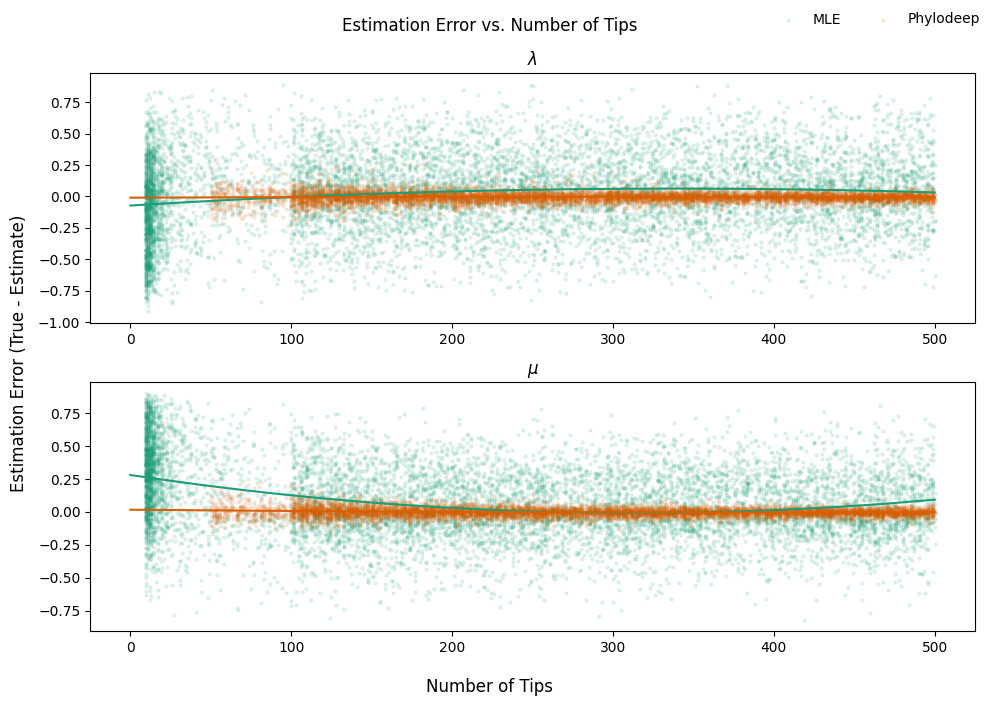

In [86]:
fig, ax = plt.subplots(figsize=(10, 7), nrows=2)

for j, (param, sub_df) in enumerate(long_data.groupby("parameter")):

    for i, (type, group) in enumerate(sub_df.groupby("model")):

        # filled_df = group.dropna(subset=["err"]).sort_values("tips")
        filled_df = group.dropna(subset=["err"])
        # filled_df = filled_df[filled_df["err"] > 0]

        # --- Fit and covariance from polyfit ---
        c, b, a = np.polyfit(filled_df["tips"], filled_df["err"], 2)
        
        # Create x-range for smooth line
        x_vals = np.linspace(0, 500, 200)
        y_hat = a + b * x_vals + c * x_vals**2
        ax[j].plot(x_vals, y_hat, color=cmap(i))
        ax[j].scatter(
            filled_df["tips"],
            filled_df["err"],
            alpha=0.1,
            label=type,
            color=cmap(i),
            s=5,
        )

    # Title per panel
    param_name = "$\\lambda$" if param == "lambda" else "$\\mu$"
    ax[j].set_title(f"{param_name}")

handles, labels = ax[0].get_legend_handles_labels()

# --- Make a single shared legend ---
fig.legend(
    handles, labels,
    loc="upper right",
    ncol=len(labels),
    frameon=False,
)
fig.suptitle("Estimation Error vs. Number of Tips")
fig.supxlabel("Number of Tips")
fig.supylabel("Estimation Error (True - Estimate)")

fig.tight_layout()
fig.savefig("./docs/presentation/images/estimation_error_vs_tips.png", dpi=300)

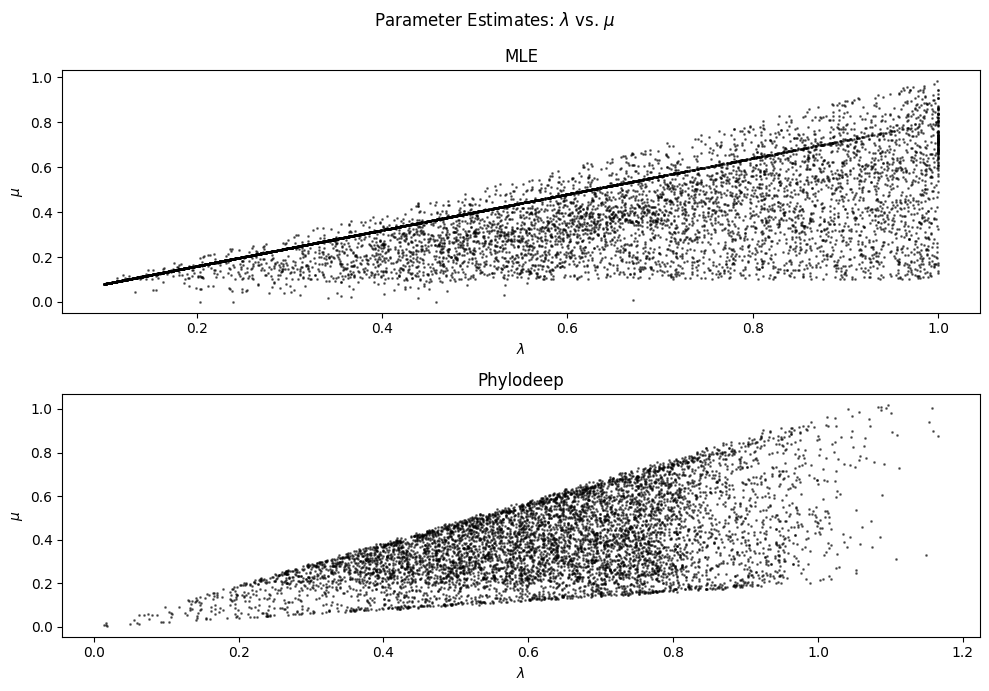

In [87]:
fig, ax = plt.subplots(figsize=(10, 7), nrows=2)

for j, (param, sub_df) in enumerate(long_data.groupby("model")):
    x_vals = sub_df[sub_df["parameter"] == "lambda"]
    y_vals = sub_df[sub_df["parameter"] == "mu"]
    ax[j].scatter(x_vals["estimate"], y_vals["estimate"], alpha=0.5, s=1, color="black")
    ax[j].set_title(param)
    ax[j].set_xlabel("$\\lambda$")
    ax[j].set_ylabel("$\\mu$")
fig.suptitle("Parameter Estimates: $\\lambda$ vs. $\\mu$")
fig.tight_layout()
fig.savefig("./docs/presentation/images/lambda_vs_mu_estimates.png")

,tree_idx,true_value,estimate,model,tips,parameter,err
0,0,0.402,0.256912,MLE,285,lambda,0.145088
1,1,0.727,0.393022,MLE,320,lambda,0.333978
2,2,0.785,0.444973,MLE,187,lambda,0.340027
3,3,0.749,0.410200,MLE,491,lambda,0.338800
4,4,0.727,0.477023,MLE,286,lambda,0.249977
...,...,...,...,...,...,...,...
34615,8650,0.823,NaN,Phylodeep,11,mu,NaN
34616,8651,0.822,NaN,Phylodeep,12,mu,NaN
34617,8652,0.005,0.004555,Phylodeep,113,mu,0.000445
34618,8653,0.855,NaN,Phylodeep,36,mu,NaN
